Imports required libraries and modules used throughout the notebook: numerical libraries, Astropy units/constants, plotting, and microlensing utilities.

In [1]:
from amoeba.Classes.accretion_disk import AccretionDisk
from amoeba.Classes.magnification_map import MagnificationMap
import amoeba.Util.util as util
import numpy as np
import numpy.random as random
from astropy.io import fits
import astropy.constants as ac
import astropy.units as au
from astropy.nddata import block_reduce
from scipy import signal
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import sys
import time as supertime


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# import mpl_style
# plt.style.use(mpl_style.style)

from microlensing.IPM.ipm import IPM
from microlensing.CCF.ccf import CCF
from microlensing.NCC.ncc import NCC
from microlensing.Stars.stars import Stars

Enable autoreload for development and set matplotlib to inline plotting for notebooks.

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


#### Create a magnification map
Prepare lensing parameter arrays used to build magnification maps in the next cells.

In [3]:
kappa_star = [0.00931642, 0.03531248, 0.06005809, 0.08395876]
kappa = [0.26874554, 0.44044909, 0.58610202 ,0.73484637]
shear = [0.2814456 , 0.43822102, 0.58440699, 0.76333608]
ipms = {}
maps = {}

Create IPM objects for each parameter set, compute magnification maps, and prepare plotting in the next cell.

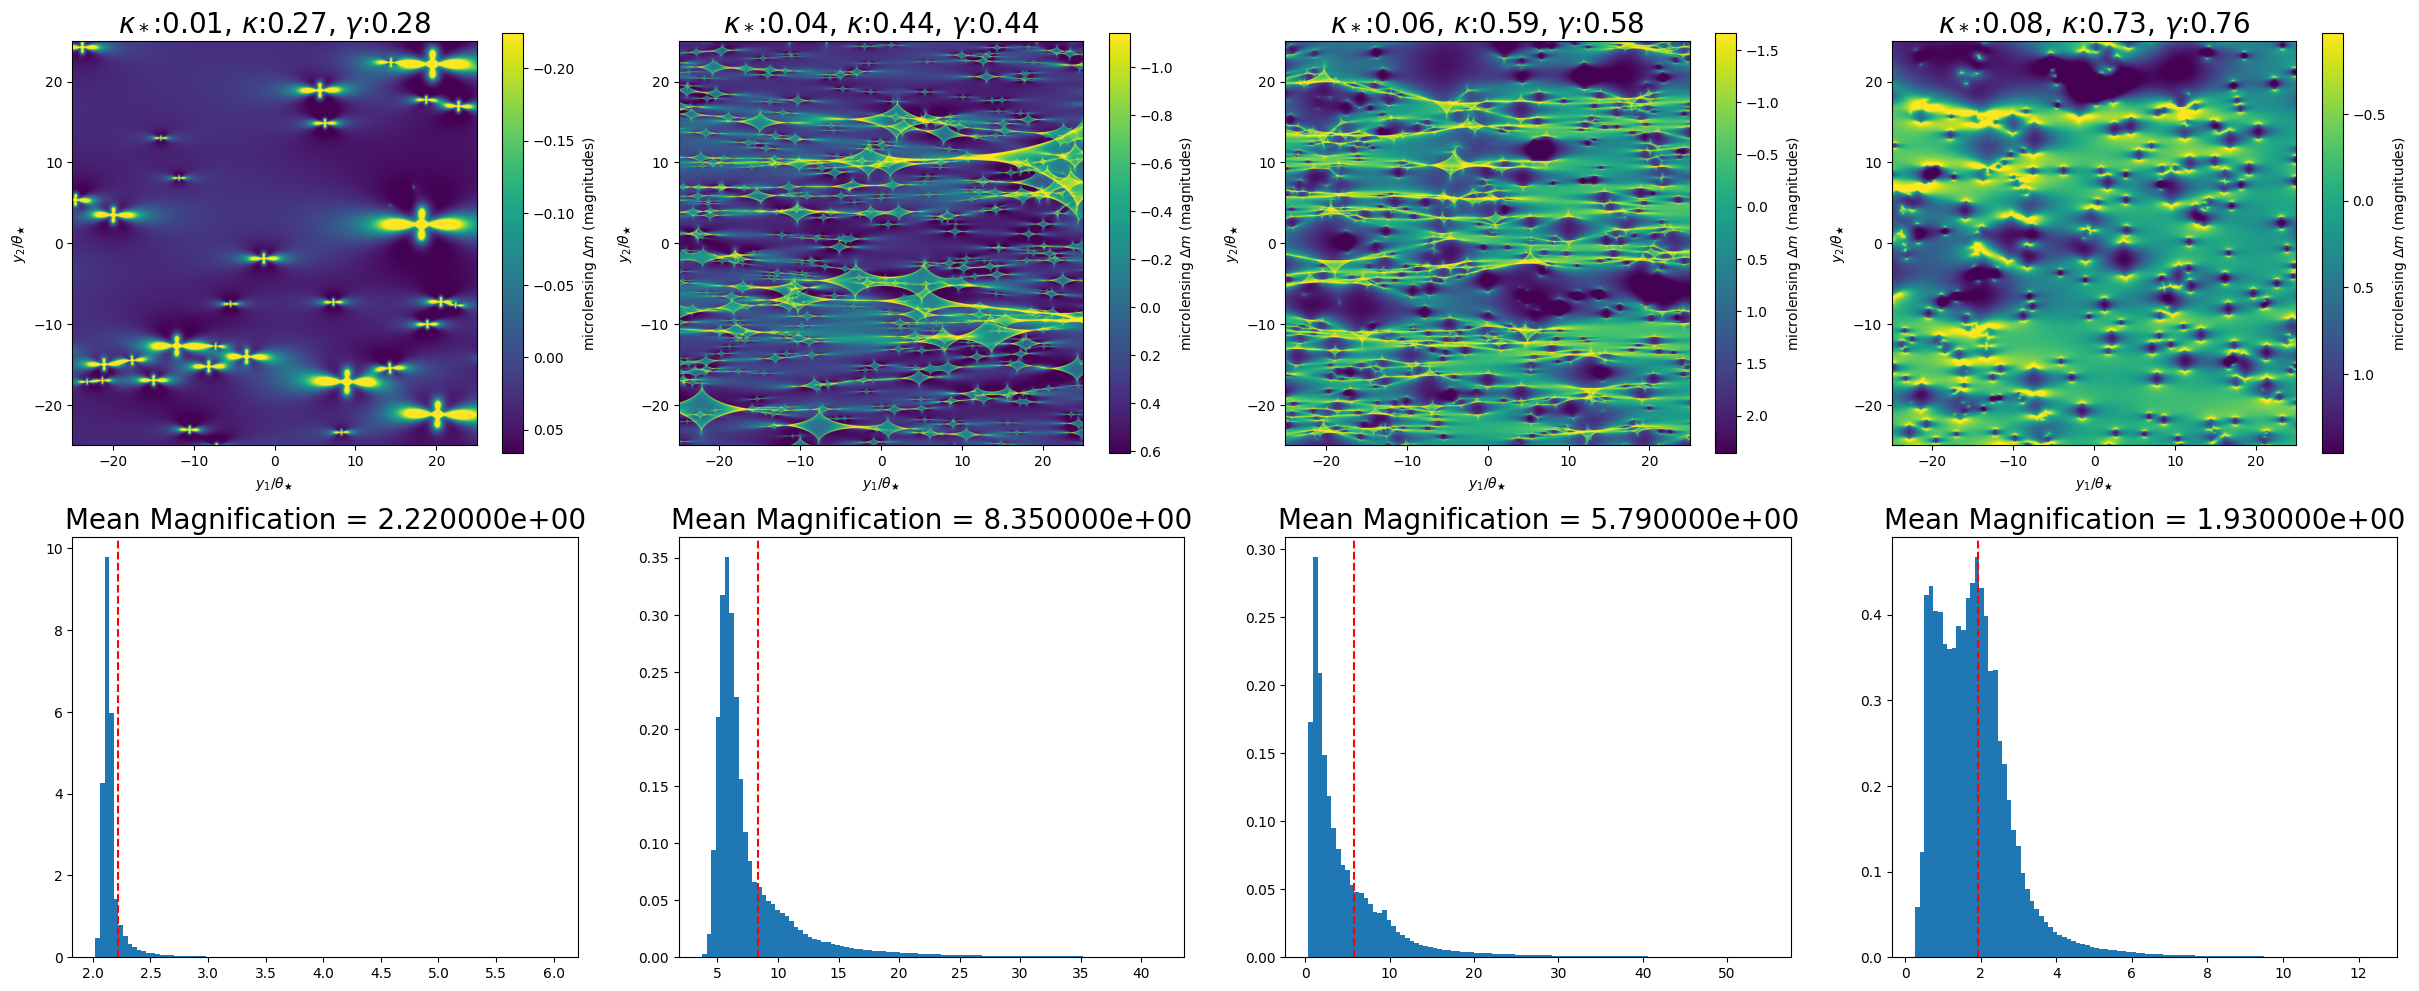

In [4]:
fig, ax = plt.subplots(2,4,figsize=(30,12))
for i in range(4):
    ipm = IPM(verbose=0, kappa_tot=kappa[i], shear=shear[i], kappa_star=kappa_star[i],
            rectangular=True, approx=True, half_length_y1=25, half_length_y2=25,
            mass_function='kroupa', m_lower=0.08, m_upper=100,
            num_pixels_y1=3500, num_pixels_y2=3500,
            write_stars=True)
    ipm.run()
    ipm.plot(ax[0][i])
    mags = ipm.magnifications
    mask = (np.abs(mags.flatten() - np.mean(mags)) < 5 * np.std(mags))
    ax[1][i].hist(mags.flatten()[mask], bins=100, density=True)
    mean_mag = np.mean(mags)
    ax[1][i].axvline(mean_mag, ls='--',color='r')
    maps[f'image_{i}'] = mags
    ipms[f'ipm_{i}'] = ipm
    rounded_mag = np.round(mean_mag,2)
    ax[0][i].set_title('$\kappa_*$:'+ f'{np.round(kappa_star[i],2)}, '+
                       '$\kappa$:' +  f'{np.round(kappa[i],2)}, '+ 
                       '$\gamma$:'+ f'{np.round(shear[i],2)}', size=20)
    ax[1][i].set_title(f'Mean Magnification = {rounded_mag:2e}',size=20)
#     fig.suptitle()
#     plt.show()

#### Creating Accretion Disk Object
Import utilities and set up parameters that define the accretion disk and driving variability signal.

In [ ]:
from amoeba.Util.util import generate_signal_from_psd, generate_signal_from_bending_power_law, create_maps
from skimage.transform import rescale

Define physical and model parameters for the source and lens (black hole mass, redshift, disk resolution, inclination, and time delays).

In [5]:
zsrc, zlens = 1.99, 0.143403537129172
# import required packages


# define an accretion disk
bh_mass = 7.781174e+08 # obtained this from kormendy ho 2013 relation between black hole mass and bulge mass
smbh_mass_exp =  np.log10(bh_mass) # solution to log_10(M_smbh/M_sun)
redshift_source = zsrc  # dimensionless # obtained this from OM10
number_grav_radii = 500  # Rg # arbitrarily set number
resolution = 100  # total px # how many pixel you want your accretion disk plane to be 
# -- higher number means less area in one pixel i.e better resolution 
eddington_ratio = 0.1  # dimensionless # ratio of mass accretion rate to eddington rate
inclination_angle = 0  # deg # inclination of accretion disk w.r.to observer
corona_height = 10 # height of x-ray corona above accretion disk

td1, td2, td3, td4 = 0, 3.901, 27.84, 2.302
time_delays = np.array([td1,td2,td3,td4])

Define observing band properties, zero points, and variability timescales used for simulations and unit conversions.

In [6]:
lsst_passband_range = np.array([3900 - 3200, 5700 - 4800, 6900-6000, 8000-7300, 9300-8300, 10600-9800])
lsst_throughput = np.array([0.2, 0.4, 0.41, 0.41, 0.41, 0.21]) # photon throughput ; this should be energy throughputs
lsst_in_nm_obs = np.array([367.1, 482.7, 622.3, 754.6, 869.1, 971.2]) 
zps = np.array([26.52,28.51,28.36,28.17,27.78,26.82])
taus = np.array([798.1, 827.9, 857.5, 880.5,897.7,911.4]) / (1 + zsrc)
# driving variability should be in the source frame
sfs =np.array([0.3817, 0.3363, 0.2979, 0.2718, 0.2541, 0.2412])


Instantiate the accretion disk model, generate a driving light curve from a bending power-law PSD, and prepare unit conversions for plotting.

pixel_size:  11489876353824.65
gravitational_radius given bh mass:  1148987635382.465
maximum radius of accretion disk in r_g:  500
np.size(self.temp_array, 0):  100


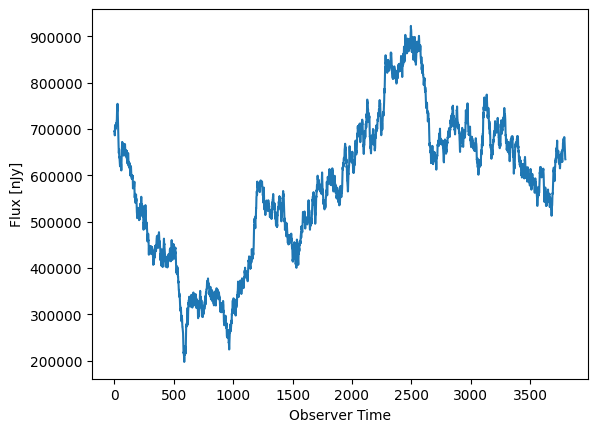

In [ ]:

lsst_in_nm_rest = lsst_in_nm_obs / (1 + zsrc)  # in nm # scaling 
colors = ['purple','blue','green','orange','red','brown']

random_seed = np.random.randint(1000)
driving_signal_strength = 1
band_names = ['u','g','r','i','z','y']
name_to_wave = dict(zip(lsst_in_nm_obs,band_names))
min_radius = 10  # Rg
spin = 0

t_max = 10  # years, by default
delta_t = (1/365) #/ (1+zsrc) # in years 

# taus = np.array([798.1, 827.9, 857.5, 880.5,897.7,911.4])/365
total_time = int(365 * (t_max+1/3) + np.max(time_delays)) # t_max number of years + 1/3rd of a year
# time_axis = np.linspace(0, total_time, int(total_time)*2)

# make some objects
agn_dictionary = create_maps(smbh_mass_exp = smbh_mass_exp,
                                 redshift_source=redshift_source,
                                   number_grav_radii=number_grav_radii,
                                   inclination_angle=inclination_angle,
                                   resolution=resolution,
                                   spin=spin,
                                   eddington_ratio=eddington_ratio ,
                                   temp_beta=0,
                                   corona_height=corona_height)

my_accretion_disk = AccretionDisk(**agn_dictionary)
u_band_static_flux = my_accretion_disk.calculate_surface_intensity_map(lsst_in_nm_rest[0]).flux_array.sum()
my_driving_signal_times,my_driving_signal = generate_signal_from_bending_power_law(
    length_of_light_curve = total_time,
    time_resolution = 1,
    log_breakpoint_frequency=np.log(1/(2*np.pi*taus[0])),
    low_frequency_slope=0,
    high_frequency_slope=2,
    mean_magnitude=u_band_static_flux,
    standard_deviation=(sfs[0]/np.sqrt(2))*u_band_static_flux, # convert from mag to flux 10
    normal_magnitude_variance=True,
    zero_point_mag=0,
    seed=random_seed,
)

driving_signal_normal_units = ((my_driving_signal/my_accretion_disk.pixel_size**2)*(au.W/au.m**2/au.m)).to(au.W/au.m**2/au.AA).to(au.erg/au.s/au.cm**2/au.AA)
plt.plot(my_driving_signal_times, driving_signal_normal_units.to(au.nJy, equivalencies = au.spectral_density(lsst_in_nm_obs[0]*au.nm)))

plt.xlabel('Observer Time')
plt.ylabel('Flux [nJy]');
# need to check units of inputs of the driving 

Convert the driving signal to magnitudes and plot it (observer-frame) to compare with simulated snapshots.

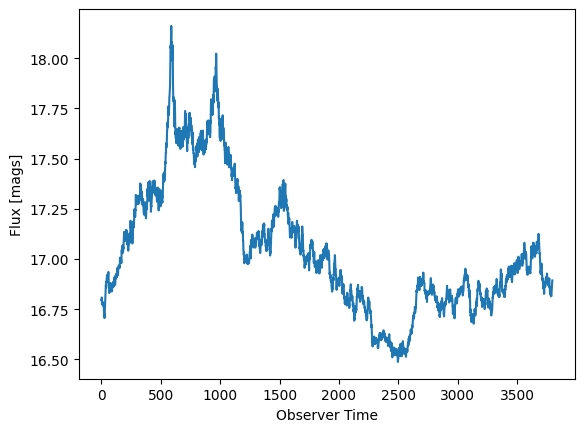

In [11]:
driving_signal_magnitude_units = -2.5 * np.log10((driving_signal_normal_units.to(au.Jy, equivalencies=au.spectral_density(lsst_in_nm_obs[0] * au.nm)) / 3631).value)
plt.plot(my_driving_signal_times, driving_signal_magnitude_units)
plt.xlabel('Observer Time')
plt.ylabel('Flux [mags]');

#### Generate snapshots
Generate time-ordered 2D image snapshots of the accretion disk for each band, convert to observed flux/magnitude, and plot points on the light curve.

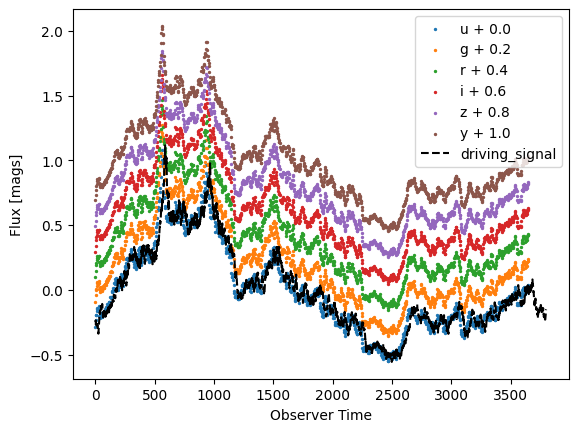

In [51]:

pixel_size = my_accretion_disk.pixel_size*au.m
snapshot_timestamps = np.arange(0.01, 3650, 3) + time_delays[0]
bands = list('ugrizy')
for b in range(6):
    b_band = lsst_in_nm_obs[b]
    b_snaps, tl_arr  = my_accretion_disk.generate_snapshots(
            b_band,
            snapshot_timestamps,
            my_driving_signal,
            driving_signal_strength,
        )

    all_r_snaps = np.array([i.flux_array for i in b_snaps])
    with_units = (all_r_snaps*(au.W/au.m**2/au.m)).to(au.W/au.m**2/au.Angstrom) * pixel_size**2
    finite_mask = np.isfinite(with_units)
    finite_data = np.where(finite_mask, with_units, 0)
    lum_dist = my_accretion_disk.lum_dist*au.m  # m -->in parsecs
    finite_data/=(4*np.pi*lum_dist**2)
    finite_data = finite_data.to(au.erg/au.s/au.cm**2/au.Angstrom)
    finite_data = finite_data.to(
        au.Jy,
        equivalencies=au.spectral_density(lsst_in_nm_obs[b] * au.nm)
    )
    slice_sums = np.sum(finite_data, axis=(1,2))
    observed_mags = -2.5*np.log10(slice_sums.value/3631)
    plt.scatter(snapshot_timestamps, observed_mags-np.mean(observed_mags)+b*0.2, s=2, label=f'{bands[b]} + {np.round(b*0.2,2)}')
driving_signal_magnitude_units = -2.5 * np.log10((driving_signal_normal_units.to(au.Jy, equivalencies=au.spectral_density(lsst_in_nm_obs[0] * au.nm)) / 3631).value)
plt.plot(my_driving_signal_times+ time_delays[0], driving_signal_magnitude_units-np.mean(driving_signal_magnitude_units), color='k', ls='--', label='driving_signal')
plt.legend();
plt.xlabel('Observer Time')
plt.ylabel('Flux [mags]');

Repeat the snapshot generation with a different driving strength (0.8) to compare amplitude effects.

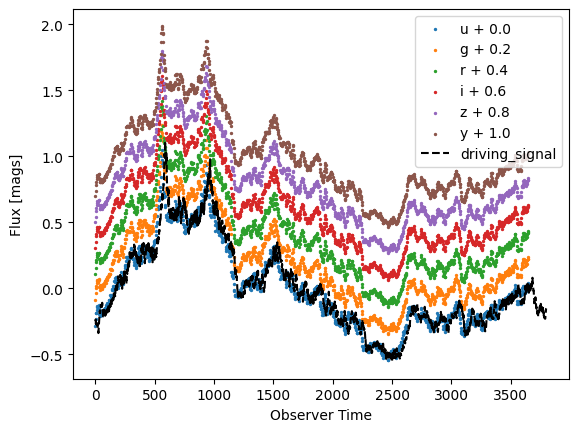

In [52]:

pixel_size = my_accretion_disk.pixel_size*au.m
snapshot_timestamps = np.arange(0.01, 3650, 3) + time_delays[0]
bands = list('ugrizy')
for b in range(6):
    b_band = lsst_in_nm_obs[b]
    b_snaps, tl_arr  = my_accretion_disk.generate_snapshots(
            b_band,
            snapshot_timestamps,
            my_driving_signal,
            0.8,
        )

    all_r_snaps = np.array([i.flux_array for i in b_snaps])
    with_units = (all_r_snaps*(au.W/au.m**2/au.m)).to(au.W/au.m**2/au.Angstrom) * pixel_size**2
    finite_mask = np.isfinite(with_units)
    finite_data = np.where(finite_mask, with_units, 0)
    lum_dist = my_accretion_disk.lum_dist*au.m  # m -->in parsecs
    finite_data/=(4*np.pi*lum_dist**2)
    finite_data = finite_data.to(au.erg/au.s/au.cm**2/au.Angstrom)
    finite_data = finite_data.to(
        au.Jy,
        equivalencies=au.spectral_density(lsst_in_nm_obs[b] * au.nm)
    )
    slice_sums = np.sum(finite_data, axis=(1,2))
    observed_mags = -2.5*np.log10(slice_sums.value/3631)
    plt.scatter(snapshot_timestamps, observed_mags-np.mean(observed_mags)+b*0.2, s=2, label=f'{bands[b]} + {np.round(b*0.2,2)}')
driving_signal_magnitude_units = -2.5 * np.log10((driving_signal_normal_units.to(au.Jy, equivalencies=au.spectral_density(lsst_in_nm_obs[0] * au.nm)) / 3631).value)
plt.plot(my_driving_signal_times+ time_delays[0], driving_signal_magnitude_units-np.mean(driving_signal_magnitude_units), color='k', ls='--', label='driving_signal')
plt.legend();
plt.xlabel('Observer Time')
plt.ylabel('Flux [mags]');

#### [future] Multiply 2D flux maps with microlensing maps